In [1]:
# STEP 1: Install and import all required libraries.
# WHY: We need tools for data handling, plotting, statistics, and machine learning.
# WHAT OUTPUT MEANS: If you see the success message, setup is complete.
# NEXT STEP: Load all race JSON files into memory.

%pip install statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import f_regression, mutual_info_regression, RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


Note: you may need to restart the kernel to use updated packages.
All libraries loaded successfully!


In [2]:
# STEP 2: Load all race JSON files into one Python list.
# WHY: The model needs a single combined dataset from all race files.
# WHAT OUTPUT MEANS:
#   - Total races loaded should be large (all files combined).
#   - Drivers per race should be 20 in this simulation.
#   - Total data points is races * 20 drivers.
# NEXT STEP: Convert nested JSON into a flat DataFrame (feature engineering).
import json, glob, os

all_races = []
data_path = os.path.join('data', 'historical_races', '*.json')

for filepath in sorted(glob.glob(data_path)):
    with open(filepath, 'r', encoding='utf-8') as f:
        all_races.extend(json.load(f))

print(f"Total races loaded: {len(all_races)}")
print(f"Drivers per race: {len(all_races[0]['strategies'])}")
print(f"Total data points (races × drivers): {len(all_races) * 20}")

Total races loaded: 30000
Drivers per race: 20
Total data points (races × drivers): 600000


In [3]:
# STEP 3: Feature engineering (convert raw race JSON to ML table).
# WHY: ML models need tabular rows/columns, not nested dictionaries.
# WHAT WE BUILD: One row = one driver in one race.
# TARGET COLUMN: finishing_position (1 is winner, 20 is last).
# WHAT OUTPUT MEANS: Check shape, columns, and first rows for sanity.
# NEXT STEP: Do dataset overview and basic statistics.

rows = []
for race in all_races:
    cfg = race['race_config']

    # Create a map from driver_id to finishing rank.
    finish_order = race['finishing_positions']
    finish_map = {driver: pos + 1 for pos, driver in enumerate(finish_order)}

    # For each start position (pos1 ... pos20), create one training row.
    for pos_key, strategy in race['strategies'].items():
        grid_pos = int(pos_key.replace('pos', ''))
        driver_id = strategy['driver_id']
        pit_stops = strategy['pit_stops']

        # Strategy-derived features.
        num_pits = len(pit_stops)
        first_pit_lap = pit_stops[0]['lap'] if num_pits > 0 else cfg['total_laps']
        last_pit_lap = pit_stops[-1]['lap'] if num_pits > 0 else 0

        # First pit timing normalized by race length (0 to 1).
        first_pit_pct = first_pit_lap / cfg['total_laps']

        # Encode tire type to numeric form for model input.
        tire_map = {'SOFT': 1, 'MEDIUM': 2, 'HARD': 3}
        starting_tire_num = tire_map.get(strategy['starting_tire'], 2)

        rows.append({
            'race_id': race['race_id'],
            'driver_id': driver_id,
            'track': cfg['track'],
            'total_laps': cfg['total_laps'],
            'base_lap_time': cfg['base_lap_time'],
            'pit_lane_time': cfg['pit_lane_time'],
            'track_temp': cfg['track_temp'],
            'grid_position': grid_pos,
            'starting_tire': starting_tire_num,
            'num_pit_stops': num_pits,
            'first_pit_lap': first_pit_lap,
            'first_pit_pct': first_pit_pct,
            'last_pit_lap': last_pit_lap,
            'finishing_position': finish_map[driver_id]
        })

df = pd.DataFrame(rows)
print(f"DataFrame shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 5 rows:")
df.head()

DataFrame shape: (600000, 14)

Columns: ['race_id', 'driver_id', 'track', 'total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp', 'grid_position', 'starting_tire', 'num_pit_stops', 'first_pit_lap', 'first_pit_pct', 'last_pit_lap', 'finishing_position']

First 5 rows:


,race_id,driver_id,track,total_laps,base_lap_time,pit_lane_time,track_temp,grid_position,starting_tire,num_pit_stops,first_pit_lap,first_pit_pct,last_pit_lap,finishing_position
0,R21072,D001,Suzuka,50,84.5,22.7,27,1,2,1,23,0.46,23,1
1,R21072,D002,Suzuka,50,84.5,22.7,27,2,2,2,12,0.24,29,4
2,R21072,D003,Suzuka,50,84.5,22.7,27,3,1,1,15,0.30,15,13
3,R21072,D004,Suzuka,50,84.5,22.7,27,4,2,2,12,0.24,33,6
4,R21072,D005,Suzuka,50,84.5,22.7,27,5,2,2,14,0.28,36,16


In [4]:
# STEP 4: Explore the dataset with summary statistics.
# WHY: Before modeling, we must understand data size, feature ranges, and coverage.
# WHAT OUTPUT MEANS:
#   - Samples confirms total rows.
#   - Features confirms number of model inputs.
#   - Descriptive stats reveal mean/std/min/max for each numeric variable.
# NEXT STEP: Study feature-target correlation patterns.
numeric_cols = ['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
                'grid_position', 'starting_tire', 'num_pit_stops',
                'first_pit_lap', 'first_pit_pct', 'last_pit_lap',
                'finishing_position']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Samples: {df.shape[0]:,}  (30,000 races x 20 drivers)")
print(f"Features: {len(numeric_cols) - 1}")
print(f"Target: finishing_position (1 = winner, 20 = last)")
print(f"\nUnique tracks: {df['track'].nunique()} - {sorted(df['track'].unique())}")
print(f"Unique drivers: {df['driver_id'].nunique()}")

print("\n--- Descriptive Statistics ---")
# Keep a named table so it can be reused later if needed (reporting/export).
summary_stats = df[numeric_cols].describe().round(3)
summary_stats

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Compare mean and 50% (median) to check skewness in each feature.")
print("2. Large min-max ranges suggest higher spread and possible outliers.")
print("3. Features with very low spread may contribute less predictive signal.")

DATASET OVERVIEW
Samples: 600,000  (30,000 races x 20 drivers)
Features: 10
Target: finishing_position (1 = winner, 20 = last)

Unique tracks: 7 - ['Bahrain', 'COTA', 'Monaco', 'Monza', 'Silverstone', 'Spa', 'Suzuka']
Unique drivers: 20

--- Descriptive Statistics ---

AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Compare mean and 50% (median) to check skewness in each feature.
2. Large min-max ranges suggest higher spread and possible outliers.
3. Features with very low spread may contribute less predictive signal.


--- Correlation with Finishing Position ---
  starting_tire       + 0.0283  #
  grid_position       + 0.0257  #
  first_pit_pct       + 0.0143  
  total_laps          + 0.0000  
  base_lap_time       + 0.0000  
  track_temp          + 0.0000  
  pit_lane_time       - 0.0000  
  num_pit_stops       - 0.0291  #
  first_pit_lap       - 0.0319  #
  last_pit_lap        - 0.0473  #


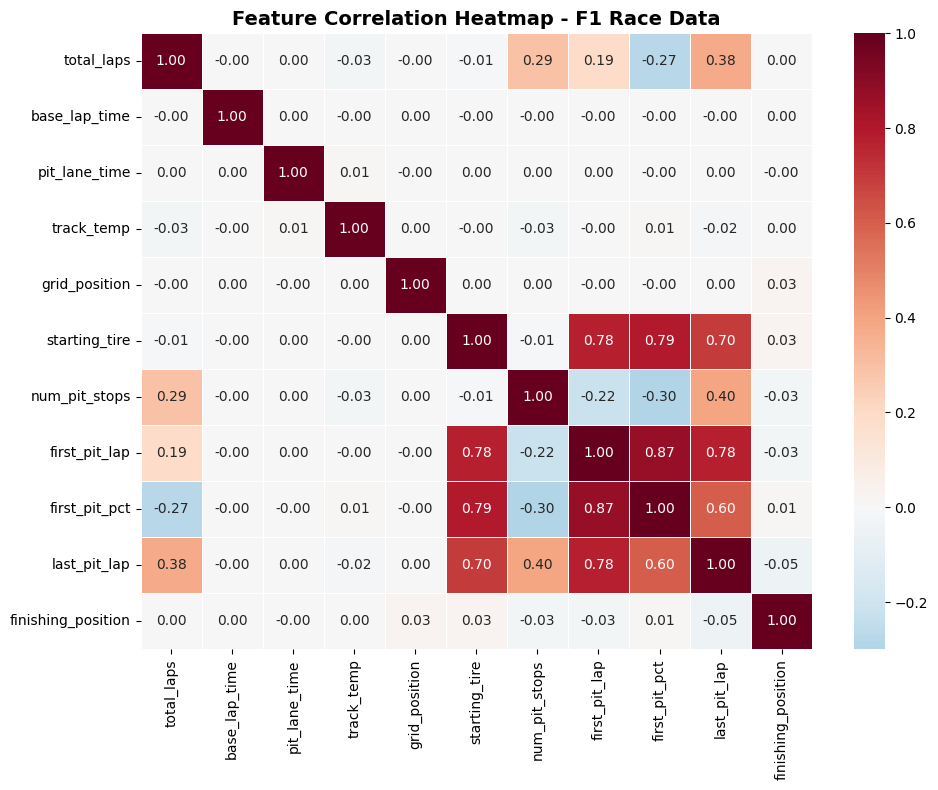


AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Positive correlation means higher values tend to worsen rank number.
2. Negative correlation means higher values tend to improve rank number.
3. Larger absolute correlation values imply stronger linear relationships.
4. In the heatmap, darker colors near +/-1 show stronger pairwise links.


In [5]:
# STEP 5: Check correlation with target and visualize full correlation matrix.
# WHY: Correlation gives a quick linear relationship signal before model training.
# WHAT OUTPUT MEANS:
#   - Positive value: higher feature tends to increase finishing_position (worse finish).
#   - Negative value: higher feature tends to decrease finishing_position (better finish).
#   - Heatmap helps spot related feature groups.
# NEXT STEP: Train a simple baseline model using only grid_position.

corr_with_target = df[numeric_cols].corr()['finishing_position'].drop('finishing_position')
corr_with_target = corr_with_target.sort_values(ascending=False)

print("--- Correlation with Finishing Position ---")
for feat, val in corr_with_target.items():
    bar = "#" * int(abs(val) * 40)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:18s}  {sign} {abs(val):.4f}  {bar}")

# Heatmap visualizes pairwise correlations among all numeric variables.
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr().round(2), annot=True, cmap='RdBu_r',
            center=0, fmt='.2f', linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap - F1 Race Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Positive correlation means higher values tend to worsen rank number.")
print("2. Negative correlation means higher values tend to improve rank number.")
print("3. Larger absolute correlation values imply stronger linear relationships.")
print("4. In the heatmap, darker colors near +/-1 show stronger pairwise links.")

SIMPLE LINEAR REGRESSION: grid_position -> finishing_position
                            OLS Regression Results                            
Dep. Variable:     finishing_position   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     397.1
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.53e-88
Time:                        15:52:28   Log-Likelihood:            -1.9024e+06
No. Observations:              600000   AIC:                         3.805e+06
Df Residuals:                  599998   BIC:                         3.805e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

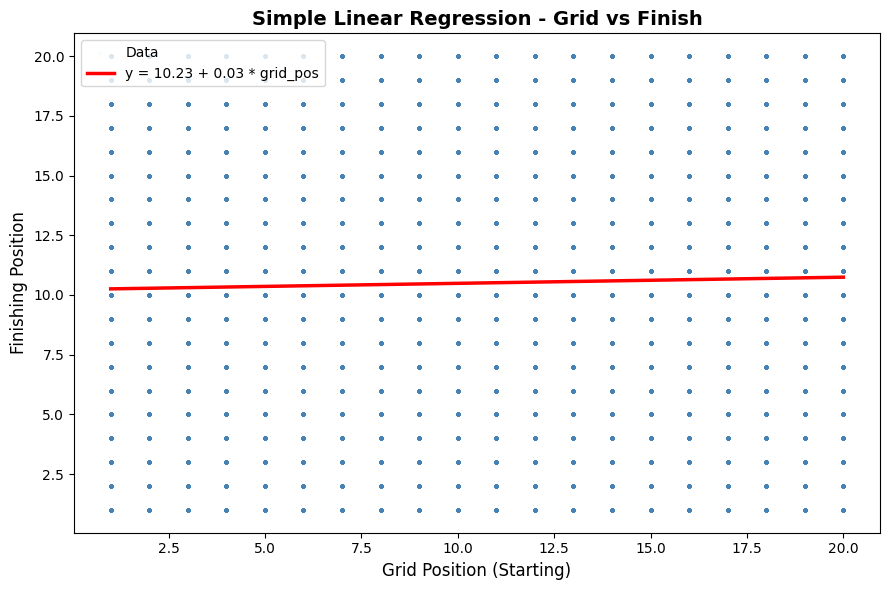


R^2 = 0.0007 - grid position alone explains 0.1% of finishing variance
Coefficient = 0.0257 - each grid spot back costs ~0.03 finishing positions
p-value = 2.53e-88 - highly significant

AFTER RESULTS: HOW TO READ THIS OUTPUT
1. The fitted red line slope shows average effect direction and strength.
2. Wider scatter around the line means more unexplained variance.
3. A very small p-value supports that the effect is statistically reliable.
4. Use this as baseline before comparing with the multi-feature model.


In [6]:
# STEP 6: Build simple linear regression with one feature (grid_position).
# WHY: This gives a clean baseline and tests the strongest intuitive predictor.
# WHAT OUTPUT MEANS:
#   - R^2: how much variation is explained by grid position alone.
#   - Coefficient: average change in finishing_position per 1 grid step back.
#   - p-value: whether the relationship is statistically significant.
# NEXT STEP: Add all features in multiple regression to check improvement.

X_simple = df[['grid_position']]
y = df['finishing_position']

X_sm = sm.add_constant(X_simple)
ols_simple = sm.OLS(y, X_sm).fit()

print("=" * 60)
print("SIMPLE LINEAR REGRESSION: grid_position -> finishing_position")
print("=" * 60)
print(ols_simple.summary())

# Scatter + fitted line shows both raw spread and model trend.
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple, y, alpha=0.02, s=5, color='steelblue', label='Data')
x_line = np.linspace(1, 20, 100)
y_line = ols_simple.params['const'] + ols_simple.params['grid_position'] * x_line
ax.plot(x_line, y_line, color='red', linewidth=2.5,
        label=f'y = {ols_simple.params["const"]:.2f} + {ols_simple.params["grid_position"]:.2f} * grid_pos')
ax.set_xlabel('Grid Position (Starting)', fontsize=12)
ax.set_ylabel('Finishing Position', fontsize=12)
ax.set_title('Simple Linear Regression - Grid vs Finish', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

r2 = ols_simple.rsquared
coef = ols_simple.params['grid_position']
pval = ols_simple.pvalues['grid_position']
print(f"\nR^2 = {r2:.4f} - grid position alone explains {r2*100:.1f}% of finishing variance")
print(f"Coefficient = {coef:.4f} - each grid spot back costs ~{coef:.2f} finishing positions")
print(f"p-value = {pval:.2e} - {'highly significant' if pval < 0.05 else 'not significant'}")

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. The fitted red line slope shows average effect direction and strength.")
print("2. Wider scatter around the line means more unexplained variance.")
print("3. A very small p-value supports that the effect is statistically reliable.")
print("4. Use this as baseline before comparing with the multi-feature model.")


In [7]:
# STEP 7: Build multiple linear regression with all engineered features.
# WHY: We want to test whether combining features improves prediction power.
# WHAT OUTPUT MEANS:
#   - Higher R^2 than simple model means added features help.
#   - Each p-value shows if that feature adds meaningful signal (given others).
#   - Adjusted R^2 helps compare models with different feature counts.
# NEXT STEP: Check multicollinearity (VIF) to verify feature stability.

feature_cols = ['total_laps', 'base_lap_time', 'pit_lane_time', 'track_temp',
                'grid_position', 'starting_tire', 'num_pit_stops',
                'first_pit_lap', 'first_pit_pct', 'last_pit_lap']

X_all = df[feature_cols]
y = df['finishing_position']

X_sm_all = sm.add_constant(X_all)
ols_multi = sm.OLS(y, X_sm_all).fit()

print("=" * 60)
print("MULTIPLE LINEAR REGRESSION: All Features -> finishing_position")
print("=" * 60)
print(ols_multi.summary())

print("\n--- Feature Significance ---")
for feat in feature_cols:
    p = ols_multi.pvalues[feat]
    coef = ols_multi.params[feat]
    direction = "worse finish as feature increases" if coef > 0 else "better finish as feature increases"
    sig = "*** SIGNIFICANT" if p < 0.05 else "    not significant"
    print(f"  {feat:18s}  coef={coef:>9.4f}  p={p:.4e}  {sig}  ({direction})")

delta_r2 = ols_multi.rsquared - ols_simple.rsquared
print(f"\nR^2 improvement: {ols_simple.rsquared:.4f} (simple) -> {ols_multi.rsquared:.4f} (multiple)")
print(f"Adjusted R^2: {ols_multi.rsquared_adj:.4f}")
print(f"Absolute R^2 gain from added features: {delta_r2:.4f}")

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Significant p-values indicate features that matter after controlling others.")
print("2. Coefficient sign tells whether a feature worsens or improves rank number.")
print("3. Use adjusted R^2 for fair comparison with different feature counts.")
print("4. Positive delta R^2 confirms added features improved explanatory power.")

MULTIPLE LINEAR REGRESSION: All Features -> finishing_position
                            OLS Regression Results                            
Dep. Variable:     finishing_position   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.059
Method:                 Least Squares   F-statistic:                     3758.
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:52:40   Log-Likelihood:            -1.8844e+06
No. Observations:              600000   AIC:                         3.769e+06
Df Residuals:                  599989   BIC:                         3.769e+06
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------

In [8]:
# STEP 8: Calculate VIF (Variance Inflation Factor).
# WHY: High VIF means features overlap too much and coefficient interpretation becomes unstable.
# WHAT OUTPUT MEANS:
#   - VIF around 1-5 is usually acceptable.
#   - VIF > 10 is often treated as high multicollinearity risk.
# NEXT STEP: Run feature selection to keep the most useful predictors.

print("--- Variance Inflation Factors (VIF) ---")
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_cols
vif_data['VIF'] = [variance_inflation_factor(X_all.values, i)
                    for i in range(X_all.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

for _, row in vif_data.iterrows():
    flag = " HIGH" if row['VIF'] > 10 else ""
    print(f"  {row['Feature']:18s}  VIF = {row['VIF']:8.2f}{flag}")

high_vif = vif_data[vif_data['VIF'] >= 10]['Feature'].tolist()
print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. VIF < 5 usually indicates acceptable overlap between features.")
print("2. VIF 5 to <10 suggests moderate multicollinearity risk.")
print("3. VIF >= 10 suggests unstable coefficients; consider dropping/combining features.")
print(f"4. High-risk features in this run: {high_vif if high_vif else 'None'}")


--- Variance Inflation Factors (VIF) ---
  base_lap_time       VIF =   255.24 HIGH
  pit_lane_time       VIF =   242.78 HIGH
  first_pit_lap       VIF =   180.74 HIGH
  first_pit_pct       VIF =   126.13 HIGH
  total_laps          VIF =   114.87 HIGH
  num_pit_stops       VIF =   109.94 HIGH
  last_pit_lap        VIF =    99.16 HIGH
  track_temp          VIF =    43.00 HIGH
  starting_tire       VIF =    24.82 HIGH
  grid_position       VIF =     4.30

AFTER RESULTS: HOW TO READ THIS OUTPUT
1. VIF < 5 usually indicates acceptable overlap between features.
2. VIF 5 to <10 suggests moderate multicollinearity risk.
3. VIF >= 10 suggests unstable coefficients; consider dropping/combining features.
4. High-risk features in this run: ['base_lap_time', 'pit_lane_time', 'first_pit_lap', 'first_pit_pct', 'total_laps', 'num_pit_stops', 'last_pit_lap', 'track_temp', 'starting_tire']


In [9]:
# STEP 9: Use three feature-selection methods to choose strong predictors.
# WHY: Different methods detect different kinds of signal (linear, non-linear, model-based).
# WHAT OUTPUT MEANS:
#   - F-Regression: stronger linear relation -> higher F score.
#   - Mutual Information: captures non-linear dependency.
#   - RFE: ranks features by iterative elimination.
# NEXT STEP: Train models using selected features for fair comparison.


print("=" * 60)
print("METHOD 1: F-Regression Scores")
print("=" * 60)
f_scores, p_values = f_regression(X_all, y)
f_df = pd.DataFrame({'Feature': feature_cols, 'F-Score': f_scores, 'p-value': p_values})
f_df = f_df.sort_values('F-Score', ascending=False)
for _, row in f_df.iterrows():
    sig = "***" if row['p-value'] < 0.001 else ""
    print(f"  {row['Feature']:18s}  F={row['F-Score']:12.2f}  p={row['p-value']:.2e}  {sig}")
print(f"Top 3 (F-regression): {list(f_df.head(3)['Feature'])}")

print(f"\n{'=' * 60}")
print("METHOD 2: Mutual Information")
print("=" * 60)
mi_scores = mutual_info_regression(X_all, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)
for _, row in mi_df.iterrows():
    bar = "#" * int(row['MI Score'] * 50)
    print(f"  {row['Feature']:18s}  MI={row['MI Score']:.4f}  {bar}")
print(f"Top 3 (Mutual Information): {list(mi_df.head(3)['Feature'])}")

print(f"\n{'=' * 60}")
print("METHOD 3: RFE (Selecting Top 5 Features)")
print("=" * 60)
rfe = RFE(LinearRegression(), n_features_to_select=5, step=1)
rfe.fit(X_all, y)
rfe_df = pd.DataFrame({'Feature': feature_cols, 'Ranking': rfe.ranking_,
                        'Selected': rfe.support_})
rfe_df = rfe_df.sort_values('Ranking')
for _, row in rfe_df.iterrows():
    sel = "SELECTED" if row['Selected'] else ""
    print(f"  {row['Feature']:18s}  Rank={int(row['Ranking'])}  {sel}")

selected_features = list(rfe_df[rfe_df['Selected']]['Feature'])
print(f"\n>>> RFE Selected Features: {selected_features}")

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Features strong across multiple methods are usually more robust.")
print("2. F-score highlights linear relevance; MI captures non-linear information.")
print("3. RFE directly supports model-building by selecting a compact feature set.")
print("4. Selected features above are used in the next training steps.")


METHOD 1: F-Regression Scores
  last_pit_lap        F=     1348.22  p=8.01e-295  ***
  first_pit_lap       F=      612.23  p=4.29e-135  ***
  num_pit_stops       F=      508.66  p=1.39e-112  ***
  starting_tire       F=      482.16  p=7.99e-107  ***
  grid_position       F=      397.09  p=2.53e-88  ***
  first_pit_pct       F=      123.34  p=1.18e-28  ***
  base_lap_time       F=        0.00  p=1.00e+00  
  pit_lane_time       F=        0.00  p=1.00e+00  
  total_laps          F=        0.00  p=1.00e+00  
  track_temp          F=        0.00  p=1.00e+00  
Top 3 (F-regression): ['last_pit_lap', 'first_pit_lap', 'num_pit_stops']

METHOD 2: Mutual Information
  first_pit_pct       MI=0.3257  ################
  last_pit_lap        MI=0.1479  #######
  first_pit_lap       MI=0.1386  ######
  starting_tire       MI=0.0307  #
  grid_position       MI=0.0019  
  total_laps          MI=0.0000  
  base_lap_time       MI=0.0000  
  track_temp          MI=0.0000  
  pit_lane_time       MI=0.0000  

In [10]:
# STEP 10: Compare statsmodels vs scikit-learn on the same selected features.
# WHY: Both implement linear regression but serve different purposes.
#   - statsmodels: deeper statistical interpretation.
#   - scikit-learn: ML workflow tools like cross-validation.
# WHAT OUTPUT MEANS: Very similar scores confirm both are consistent implementations.
# NEXT STEP: Train a non-linear model (KNN) and tune it.

X_sel = df[selected_features]
y = df['finishing_position']

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
ols_sel = sm.OLS(y_train, X_train_sm).fit()
y_pred_sm = ols_sel.predict(X_test_sm)

lr_sk = LinearRegression()
lr_sk.fit(X_train, y_train)
y_pred_sk = lr_sk.predict(X_test)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

print("=" * 60)
print("FRAMEWORK COMPARISON: Statsmodels vs Scikit-learn")
print("=" * 60)
print(f"\n  {'Metric':<20s}  {'Statsmodels':>12s}  {'Scikit-learn':>12s}")
print(f"  {'-'*20}  {'-'*12}  {'-'*12}")
for name, func in [('R^2', r2_score), ('MAE', mean_absolute_error), ('RMSE', rmse)]:
    sm_val = func(y_test, y_pred_sm)
    sk_val = func(y_test, y_pred_sk)
    print(f"  {name:<20s}  {sm_val:12.4f}  {sk_val:12.4f}")

cv_scores = cross_val_score(lr_sk, X_train, y_train, cv=5, scoring='r2')
print(f"\n  5-Fold CV R^2 (sklearn only): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
print(f"  Individual folds: {[f'{s:.4f}' for s in cv_scores]}")

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Similar metrics indicate both libraries are learning equivalent linear patterns.")
print("2. CV mean estimates expected test performance on unseen splits.")
print("3. Lower CV standard deviation means more stable model behavior.")


FRAMEWORK COMPARISON: Statsmodels vs Scikit-learn

  Metric                 Statsmodels  Scikit-learn
  --------------------  ------------  ------------
  R^2                         0.0549        0.0549
  MAE                         4.8286        4.8286
  RMSE                        5.6109        5.6109

  5-Fold CV R^2 (sklearn only): 0.0553 +/- 0.0009
  Individual folds: ['0.0570', '0.0551', '0.0545', '0.0546', '0.0552']

AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Similar metrics indicate both libraries are learning equivalent linear patterns.
2. CV mean estimates expected test performance on unseen splits.
3. Lower CV standard deviation means more stable model behavior.


Training samples (sampled): 50,000
Test samples: 120,000

Best K         : 20
Best Weights   : uniform
Best CV R^2    : 0.2254


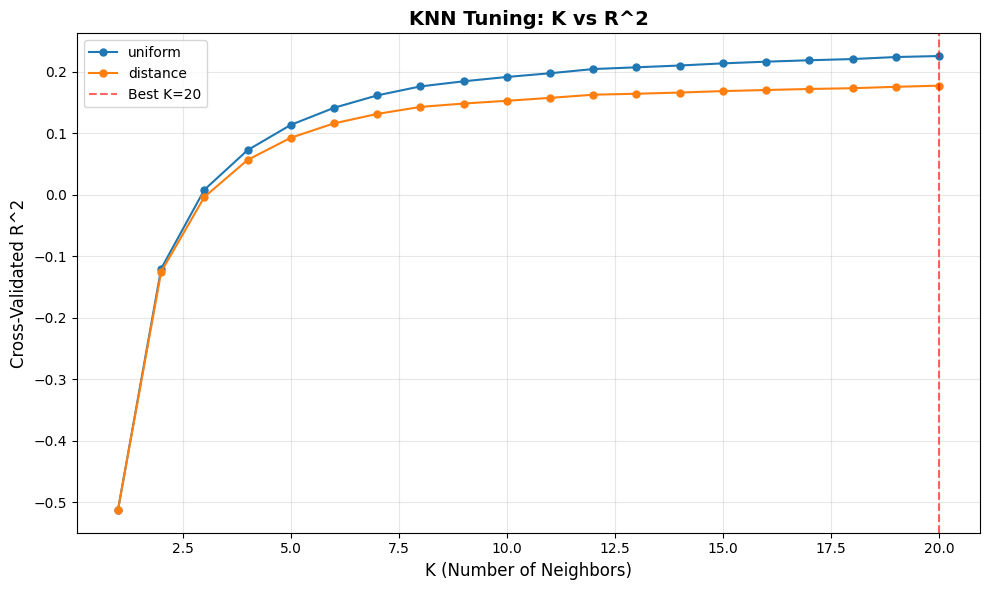


AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Highest curve point indicates strongest K for each weighting choice.
2. Very low K can overfit; very high K can oversmooth.
3. The red dashed line marks the final K carried into final comparison.


In [11]:
# STEP 11: Train and tune KNN regression.
# WHY: KNN can capture local non-linear patterns that linear regression may miss.
# IMPORTANT: KNN is slow on very large data, so we sample training rows for speed.
# WHAT OUTPUT MEANS:
#   - Best K and weights are chosen by cross-validated R^2.
#   - K vs R^2 plot shows performance trend across neighbor counts.
# NEXT STEP: Compare best KNN against linear regression on the same test set.

X_sel = df[selected_features]
y = df['finishing_position']

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42)

sample_idx = np.random.RandomState(42).choice(len(X_train_full), size=50000, replace=False)
X_train = X_train_full.iloc[sample_idx]
y_train = y_train_full.iloc[sample_idx]

print(f"Training samples (sampled): {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

# Scaling is required for distance-based algorithms like KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {'n_neighbors': list(range(1, 21)),
              'weights': ['uniform', 'distance']}
grid = GridSearchCV(KNeighborsRegressor(), param_grid,
                    cv=3, scoring='r2', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print(f"\nBest K         : {grid.best_params_['n_neighbors']}")
print(f"Best Weights   : {grid.best_params_['weights']}")
print(f"Best CV R^2    : {grid.best_score_:.4f}")

results = pd.DataFrame(grid.cv_results_)
fig, ax = plt.subplots(figsize=(10, 6))
for w in ['uniform', 'distance']:
    mask = results['param_weights'] == w
    ax.plot(results[mask]['param_n_neighbors'], results[mask]['mean_test_score'],
            'o-', label=w, markersize=5)
ax.axvline(grid.best_params_['n_neighbors'], color='red', linestyle='--',
           alpha=0.6, label=f"Best K={grid.best_params_['n_neighbors']}")
ax.set_xlabel('K (Number of Neighbors)', fontsize=12)
ax.set_ylabel('Cross-Validated R^2', fontsize=12)
ax.set_title('KNN Tuning: K vs R^2', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Highest curve point indicates strongest K for each weighting choice.")
print("2. Very low K can overfit; very high K can oversmooth.")
print("3. The red dashed line marks the final K carried into final comparison.")

In [12]:
# STEP 12: Final head-to-head model comparison on the same test data.
# WHY: Fair comparison requires same features, same split, and same evaluation metrics.
# WHAT OUTPUT MEANS:
#   - For R^2 and CV mean, higher is better.
#   - For MAE/RMSE/CV std, lower is better.
#   - Winner per metric helps summarize strengths.
# NEXT STEP: Use diagnostic plots to inspect error behavior visually.

lr_final = LinearRegression()
lr_final.fit(X_train_scaled, y_train)
y_pred_lr = lr_final.predict(X_test_scaled)

best_knn = grid.best_estimator_
y_pred_knn = best_knn.predict(X_test_scaled)

cv_lr = cross_val_score(lr_final, X_train_scaled, y_train, cv=5, scoring='r2')
cv_knn = cross_val_score(best_knn, X_train_scaled, y_train, cv=5, scoring='r2')

print("=" * 70)
print("FINAL COMPARISON: Linear Regression vs KNN")
print("=" * 70)
metrics = {
    'R^2':          (r2_score(y_test, y_pred_lr),    r2_score(y_test, y_pred_knn)),
    'MAE':         (mean_absolute_error(y_test, y_pred_lr), mean_absolute_error(y_test, y_pred_knn)),
    'RMSE':        (rmse(y_test, y_pred_lr),        rmse(y_test, y_pred_knn)),
    'CV R^2 mean':  (cv_lr.mean(),                   cv_knn.mean()),
    'CV R^2 std':   (cv_lr.std(),                    cv_knn.std()),
}

print(f"\n  {'Metric':<15s}  {'Linear Reg':>12s}  {'KNN':>12s}  {'Winner':>14s}")
print(f"  {'-'*15}  {'-'*12}  {'-'*12}  {'-'*14}")
lr_wins = 0
for metric, (lr_v, knn_v) in metrics.items():
    if metric in ['R^2', 'CV R^2 mean']:
        winner = 'Linear Reg' if lr_v > knn_v else 'KNN'
    elif metric == 'CV R^2 std':
        winner = 'Linear Reg' if lr_v < knn_v else 'KNN'
    else:
        winner = 'Linear Reg' if lr_v < knn_v else 'KNN'
    if winner == 'Linear Reg':
        lr_wins += 1
    print(f"  {metric:<15s}  {lr_v:12.4f}  {knn_v:12.4f}  <- {winner}")

knn_wins = len(metrics) - lr_wins
print(f"\n  Score: Linear Reg {lr_wins}/{len(metrics)} | KNN {knn_wins}/{len(metrics)}")
print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Higher R^2 and CV mean indicate stronger predictive quality.")
print("2. Lower MAE/RMSE indicate lower absolute prediction error.")
print("3. Lower CV std indicates better consistency across folds.")
if lr_wins > knn_wins:
    print("4. Overall reading: Linear Regression is more reliable here.")
elif knn_wins > lr_wins:
    print("4. Overall reading: KNN is capturing stronger non-linear signal here.")
else:
    print("4. Overall reading: Tie; choose based on interpretability vs flexibility.")

FINAL COMPARISON: Linear Regression vs KNN

  Metric             Linear Reg           KNN          Winner
  ---------------  ------------  ------------  --------------
  R^2                    0.0547        0.2225  <- KNN
  MAE                    4.8301        4.1421  <- KNN
  RMSE                   5.6113        5.0893  <- KNN
  CV R^2 mean            0.0522        0.2285  <- KNN
  CV R^2 std             0.0030        0.0072  <- Linear Reg

  Score: Linear Reg 1/5 | KNN 4/5

AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Higher R^2 and CV mean indicate stronger predictive quality.
2. Lower MAE/RMSE indicate lower absolute prediction error.
3. Lower CV std indicates better consistency across folds.
4. Overall reading: KNN is capturing stronger non-linear signal here.


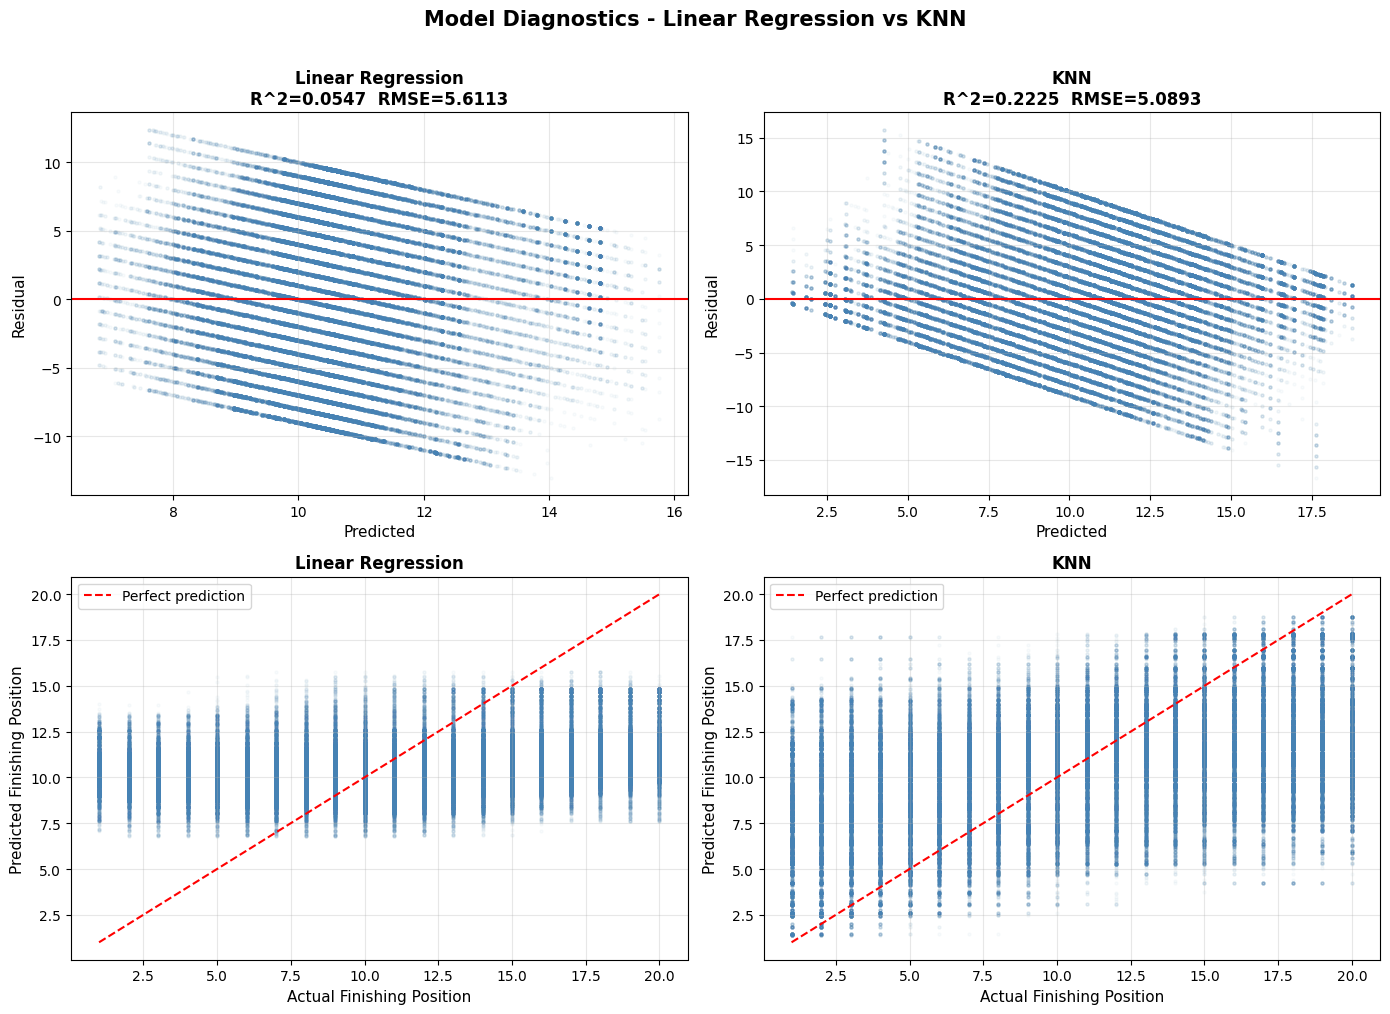


AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Residual clouds should be centered around zero with no visible pattern.
2. Funnel shapes suggest non-constant variance.
3. In actual-vs-predicted plots, points nearer the diagonal are better.
4. Systematic off-diagonal trends indicate prediction bias by rank range.


In [13]:
# STEP 13: Diagnostic plots for error analysis.
# WHY: Metrics alone are not enough; visuals reveal bias and error structure.
# WHAT OUTPUT MEANS:
#   - Residual plot: points should be centered around zero without clear pattern.
#   - Actual vs Predicted: closer to diagonal means better predictions.
# NEXT STEP: Print final summary with key findings and winner.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: residual diagnostics (predicted value vs error).
for ax, name, y_pred in zip(axes[0], ['Linear Regression', 'KNN'],
                              [y_pred_lr, y_pred_knn]):
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.03, s=5, color='steelblue')
    ax.axhline(0, color='red', linewidth=1.5)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Residual', fontsize=11)
    ax.set_title(f'{name}\nR^2={r2_score(y_test, y_pred):.4f}  '
                 f'RMSE={rmse(y_test, y_pred):.4f}',
                 fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

# Bottom row: calibration check (actual vs predicted).
for ax, name, y_pred in zip(axes[1], ['Linear Regression', 'KNN'],
                              [y_pred_lr, y_pred_knn]):
    ax.scatter(y_test, y_pred, alpha=0.03, s=5, color='steelblue')
    ax.plot([1, 20], [1, 20], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Finishing Position', fontsize=11)
    ax.set_ylabel('Predicted Finishing Position', fontsize=11)
    ax.set_title(f'{name}', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Diagnostics - Linear Regression vs KNN',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Residual clouds should be centered around zero with no visible pattern.")
print("2. Funnel shapes suggest non-constant variance.")
print("3. In actual-vs-predicted plots, points nearer the diagonal are better.")
print("4. Systematic off-diagonal trends indicate prediction bias by rank range.")

In [14]:
# STEP 14: Final project summary.
# WHY: Consolidate key outcomes in one readable block for report/viva use.
# WHAT OUTPUT MEANS: Quick snapshot of dataset size, selected features, best KNN settings,
# and final model performance side by side.
# END: You can now state the winning model with evidence.

print("=" * 70)
print("PROJECT SUMMARY - F1 Race Strategy Regression Analysis")
print("=" * 70)
print(f"""
Dataset     : F1 Race Simulation ({len(all_races):,} races, {df.shape[0]:,} driver entries)
Target      : Finishing position (1-20)
Features    : {len(feature_cols)} engineered from race config + strategy
Selected    : {selected_features} (via RFE)
Best KNN K  : {grid.best_params_['n_neighbors']} (weights={grid.best_params_['weights']})

Results:
  Linear Regression  R^2 = {r2_score(y_test, y_pred_lr):.4f}  |  RMSE = {rmse(y_test, y_pred_lr):.4f}
  KNN Regression     R^2 = {r2_score(y_test, y_pred_knn):.4f}  |  RMSE = {rmse(y_test, y_pred_knn):.4f}

Winner: {'Linear Regression' if r2_score(y_test, y_pred_lr) > r2_score(y_test, y_pred_knn) else 'KNN Regression'}
""")

print("\n" + "=" * 60)
print("AFTER RESULTS: HOW TO READ THIS OUTPUT")
print("=" * 60)
print("1. Use R^2 to discuss explained variance and RMSE for practical error size.")
print("2. If performance is close, prefer the simpler model for interpretability.")
print("3. If one model wins on both R^2 and RMSE, it is the stronger final model.")

PROJECT SUMMARY - F1 Race Strategy Regression Analysis

Dataset     : F1 Race Simulation (30,000 races, 600,000 driver entries)
Target      : Finishing position (1-20)
Features    : 10 engineered from race config + strategy
Selected    : ['total_laps', 'first_pit_lap', 'num_pit_stops', 'starting_tire', 'first_pit_pct'] (via RFE)
Best KNN K  : 20 (weights=uniform)

Results:
  Linear Regression  R^2 = 0.0547  |  RMSE = 5.6113
  KNN Regression     R^2 = 0.2225  |  RMSE = 5.0893

Winner: KNN Regression


AFTER RESULTS: HOW TO READ THIS OUTPUT
1. Use R^2 to discuss explained variance and RMSE for practical error size.
2. If performance is close, prefer the simpler model for interpretability.
3. If one model wins on both R^2 and RMSE, it is the stronger final model.
